In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/master_ecommerce.csv")


In [2]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [3]:
cohort = df[
    [
        "customer_unique_id",
        "order_purchase_timestamp"
    ]
].copy()

In [4]:
cohort = cohort.drop_duplicates()

In [6]:
cohort["PurchaseMonth"] = (
    cohort["order_purchase_timestamp"].dt.to_period("M")
)

In [7]:
cohort["CohortMonth"] = (
    cohort.groupby("customer_unique_id")["PurchaseMonth"].transform("min")
)

In [8]:
purchase_year = cohort["PurchaseMonth"].dt.year
purchase_month = cohort["PurchaseMonth"].dt.month

cohort_year = cohort["CohortMonth"].dt.year
cohort_month = cohort["CohortMonth"].dt.month

In [9]:
cohort["CohortIndex"] = (
    (purchase_year - cohort_year) * 12 + (purchase_month - cohort_month) + 1)

In [12]:
cohort_data = (
    cohort.groupby(["CohortMonth", "CohortIndex"])
["customer_unique_id"].nunique().reset_index())

In [14]:
cohort_counts = cohort_data.pivot(
    index = "CohortMonth",
    columns = "CohortIndex",
    values = "customer_unique_id"
)

In [16]:
retention = cohort_counts.divide(cohort_counts.iloc[:,0], axis = 0)

retention = retention * 100

In [17]:
retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.384615,NaN,NaN,0.384615,NaN,0.384615,NaN,0.384615,NaN,0.384615,NaN,0.384615,0.769231,0.769231
2016-12,100.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.283688,0.283688,0.141844,0.425532,0.141844,0.425532,0.141844,NaN,NaN,0.425532,0.141844,0.567376,0.425532,0.141844,0.141844,0.283688,0.425532,0.141844,NaN
2017-02,100.0,0.191083,0.318471,0.063694,0.445860,0.127389,0.254777,0.191083,0.063694,0.191083,0.127389,0.318471,0.127389,0.191083,0.127389,0.063694,0.063694,0.191083,NaN,NaN
2017-03,100.0,0.447883,0.366450,0.366450,0.366450,0.162866,0.162866,0.325733,0.325733,0.081433,0.325733,0.122150,0.203583,0.122150,0.162866,0.244300,0.081433,0.122150,NaN,NaN


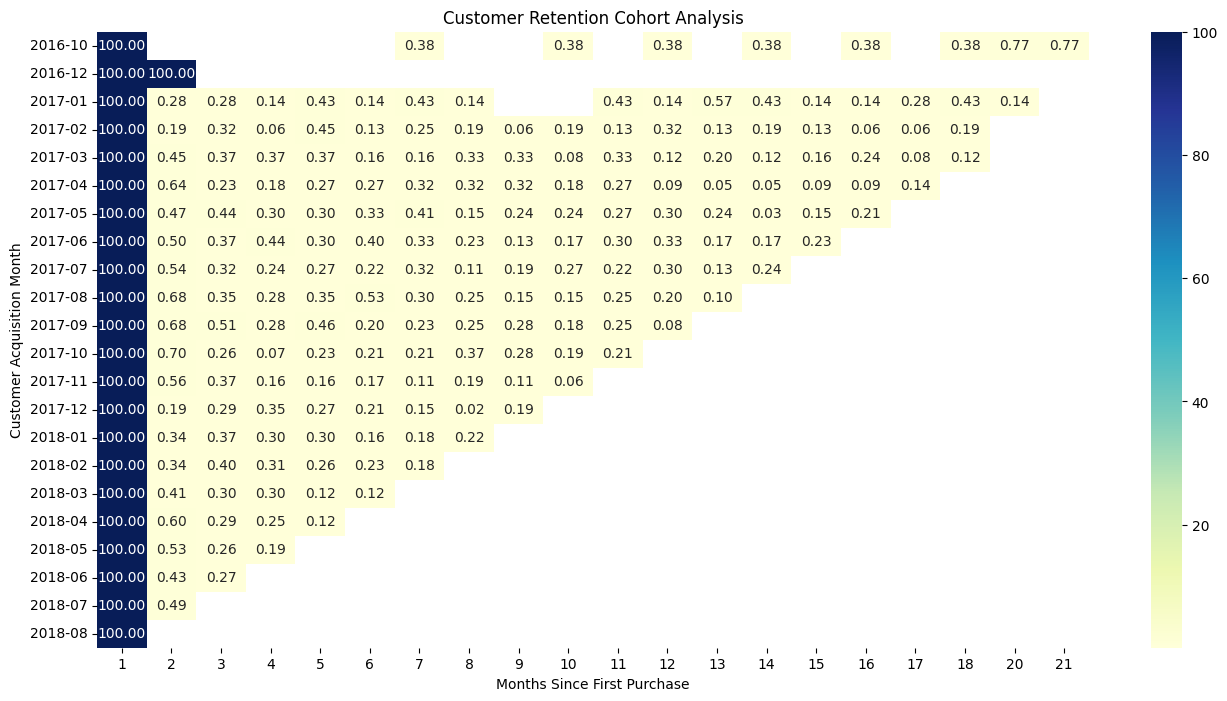

In [22]:
plt.figure(figsize=(16,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Customer Retention Cohort Analysis")
plt.ylabel("Customer Acquisition Month")
plt.xlabel("Months Since First Purchase")

plt.show()

In [21]:
total_customers = df["customer_unique_id"].nunique()

repeat_customers = (
    df.groupby("customer_unique_id")["order_id"]
      .nunique()
      .gt(1)
      .sum()
)

repeat_rate = repeat_customers / total_customers * 100

print("Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Rate:", round(repeat_rate,2), "%")

Customers: 92075
Repeat Customers: 2741
Repeat Rate: 2.98 %


Business Insight

Customer Retention Insights
1. Customer retention declines sharply after the first purchase month.

2. Most customers do not make repeat purchases, indicating a low retention business model.

3. Retention stabilizes at a very low level in later months, suggesting a small group of loyal customers continues purchasing.

4. The company appears to rely heavily on new customer acquisition rather than repeat purchases for revenue growth.

Recommendations

1. Introduce loyalty and rewards programs.

2. Offer personalized promotions to first-time buyers.

3. Implement email remarketing campaigns.

4. Develop subscription or membership-based offerings to increase repeat purchases.